# CPJUMP1 → SpatialData

Builds one [SpatialData](https://spatialdata.scverse.org) object per plate from the JUMP pilot (`cpg0000-jump-pilot`, `source_4`), the batch published as [CPJUMP1](https://github.com/jump-cellpainting/2024_Chandrasekaran_NatureMethods_CPJUMP1) ([Chandrasekaran et al. 2024](https://www.nature.com/articles/s41592-024-02241-6)).

`cpjump1_to_anndata.ipynb` reads the same batch into an AnnData of wells x CellProfiler features.
This notebook keeps that table and adds what the AnnData throws away, the pixels:

| SpatialData element | Holds |
| --- | --- |
| Images | one element per field of view, eight channels |
| Labels | the Nuclei, Cells and Cytoplasm segmentations as pixel masks |
| Shapes | one circle per well, so the well-level table has something to annotate |
| Tables | the well x feature profile for the whole plate, and the per-cell measurements of the fields loaded |

Objects go into Labels rather than Shapes because CellProfiler is pixel-based throughout: it measures on masks, and its shape features are computed from the pixels rather than from a polygon.
Converting them to polygons would be a lossy step taken for no reason.

Each element lives in three coordinate systems - its own field, its well, and its plate - so the fields of a well can be laid out as a mosaic and the wells as a plate map.

The gallery stores the images for this source alone in the tens of terabytes, so the notebook takes two wells from each of two plates and builds around them.
The well-level tables are complete: 384 wells per plate either way.

## Fetching

Roughly 700 MB.
`aws` needs no credentials for the gallery, only `--no-sign-request`.

```bash
S3=s3://cellpainting-gallery/cpg0000-jump-pilot/source_4
ROOT=~/data/cpg0000-jump-pilot
BATCH=2020_11_04_CPJUMP1

for spec in "BR00116991 BR00116991__2020-11-05T19_51_35-Measurement1" \
            "BR00117026 BR00117026__2020-11-06T07_39_45-Measurement1"; do
  set -- $spec
  aws s3 cp --no-sign-request \
    $S3/workspace/profiles/$BATCH/$1/${1}_normalized_feature_select_negcon_batch.csv.gz \
    $ROOT/workspace/profiles/$BATCH/$1/
  aws s3 cp --no-sign-request $S3/workspace/load_data_csv/$BATCH/$1/load_data.csv \
    $ROOT/workspace/load_data_csv/$BATCH/$1/
  for W in A02 C09; do
    aws s3 sync --no-sign-request $S3/workspace/analysis/$BATCH/$1/analysis/ \
      $ROOT/workspace/analysis/$BATCH/$1/analysis/ \
      --exclude '*' --include "$1-$W-*/*" --exclude '*/Cytoplasm.csv' --exclude '*/Experiment.csv'
  done
  aws s3 sync --no-sign-request $S3/images/$BATCH/images/$2/Images/ \
    $ROOT/images/$BATCH/images/$2/Images/ \
    --exclude '*' --include 'r01c02f*p01-*.tiff' --include 'r03c09f*p01-*.tiff'
done
```

`Cytoplasm.csv` is skipped because the cytoplasm mask is the cell mask minus the nucleus mask, which is how CellProfiler defines it, and the per-cytoplasm features are not needed here.
The image file names encode the well as `r<row>c<column>`, hence `r01c02` for A02 and `r03c09` for C09.

In [1]:
from __future__ import annotations

import logging
import warnings
from collections.abc import Mapping
from pathlib import Path

import anndata as ad
import geopandas as gpd
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize
from shapely import Point
from spatialdata import get_pyramid_levels
from spatialdata.models import Image2DModel, Labels2DModel, ShapesModel, TableModel
from spatialdata.transformations import Identity, Translation

import cell_painting_io as cpio
from cell_painting_io import spatial as cps

DATA_ROOT = Path("~/data/cpg0000-jump-pilot").expanduser()
S3_PREFIX = "s3://cellpainting-gallery/cpg0000-jump-pilot/source_4/"
BATCH = "2020_11_04_CPJUMP1"
PLATES = ("BR00116991", "BR00117026")
WELLS = ("A02", "C09")
CHANNELS = ("DNA", "RNA", "ER", "AGP", "Mito", "Brightfield", "HighZBF", "LowZBF")
PLATE_FORMAT = 384

# ome-zarr logs a line per label element on read, and spatialdata-plot warns once per element it subsets out
logging.getLogger("ome_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The table is annotating .*, which is not present")

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The two plates and the two wells

Both plates carry the same compound platemap and were imaged 24 h after treatment; they differ in cell line, A549 against U2OS.
That makes them a fair test of whether two plate objects concatenate, since every element name has to stay distinct while the tables have to line up.

The wells are chosen from the plate's own annotation rather than fixed by hand: the first DMSO negative control, and the first of the diverse positive controls.
On this platemap that is A02 and C09, the latter treated with CYT-997, a tubulin polymerization inhibitor.

In [2]:
def read_well_profile(plate: str) -> ad.AnnData:
    path = DATA_ROOT / "workspace/profiles" / BATCH / plate / f"{plate}_normalized_feature_select_negcon_batch.csv.gz"
    adata = cpio.read_profiles(path, index_columns=("Plate", "Well"))
    cpio.annotate_features(adata.var)
    for column in ["Plate", "Well", "pert_type", "control_type", "pert_iname"]:
        adata.obs[column] = adata.obs[column].astype("category")
    return adata


profile = read_well_profile(PLATES[0])
profile.obs.loc[profile.obs["Well"].isin(WELLS), ["Well", "pert_iname", "pert_type", "control_type"]]

,Well,pert_iname,pert_type,control_type
well,,,,
BR00116991:A02,A02,DMSO,control,negcon
BR00116991:C09,C09,CYT-997,control,poscon_diverse


## Where the fields sit

`load_data.csv` carries the stage coordinates the microscope wrote for every field: `Metadata_PositionX` and `Metadata_PositionY` in metres relative to the centre of the well, y pointing up, alongside the pixel size and the image size.

That is the whole reason a well coordinate system is possible here.
Without those coordinates each field would have to stay in its own frame, and objects from different fields of one well could not be compared in space at all.

`cell_painting_io.spatial.fov_offsets` turns the stage coordinates into pixel translations: it flips y, so the offsets can be used directly as `(y, x)` translations on an image whose row index grows downwards, and puts the origin at the corner of a well's top-left field, shared across wells so that every well of the plate uses one frame.
Offsets into the plate frame then add the nominal well pitch of the plate format, 4.5 mm for 384 wells.
The pitch is an assumption about the plate, not a measurement, since the stage coordinates are relative to each well; it is the one number here that a different plate manufacturer could invalidate.

In [3]:
def read_load_data(plate: str) -> pd.DataFrame:
    frame = pd.read_csv(DATA_ROOT / "workspace/load_data_csv" / BATCH / plate / "load_data.csv")
    return frame.set_index(["Metadata_Well", "Metadata_Site"]).rename_axis(["well", "site"]).sort_index()


def pixel_size_of(load_data: pd.DataFrame) -> float:
    resolutions = np.unique(load_data[["Metadata_ImageResolutionX", "Metadata_ImageResolutionY"]].to_numpy().round(12))
    if resolutions.size != 1:
        raise ValueError(f"the plate mixes pixel sizes: {resolutions}")
    return float(resolutions.item())


def plate_offsets(load_data: pd.DataFrame, pixel_size: float) -> pd.DataFrame:
    positions = pd.DataFrame(
        {
            "well": load_data.index.get_level_values("well"),
            "x": load_data["Metadata_PositionX"].to_numpy(float),
            "y": load_data["Metadata_PositionY"].to_numpy(float),
        },
        index=load_data.index,
    )
    return cps.fov_offsets(positions, pixel_size=pixel_size, plate_format=PLATE_FORMAT)


load_data = read_load_data(PLATES[0])
pixel_size = pixel_size_of(load_data)
shape = (int(load_data["Metadata_ImageSizeY"].iloc[0]), int(load_data["Metadata_ImageSizeX"].iloc[0]))
print(
    f"{pixel_size * 1e6:.4f} um per pixel, {shape[0]}x{shape[1]} px per field, {len(load_data.loc['A02'])} fields per well"
)

0.5980 um per pixel, 1080x1080 px per field, 9 fields per well


The nine fields of a well are not a 3x3 block.
They sample nine positions of a 4x4 grid, so laying them out in the well frame leaves seven holes; the offsets are multiples of the field size, meaning the fields abut without overlapping.

In [4]:
offsets = plate_offsets(load_data, pixel_size)
(offsets.loc["A02"] / shape[0]).round(2)

,well_y,well_x,plate_y,plate_x
site,,,,
1,1.0,1.0,1.0,7.97
2,0.0,0.0,0.0,6.97
3,0.0,2.0,0.0,8.97
4,1.0,3.0,1.0,9.97
5,2.0,0.0,2.0,6.97
6,2.0,2.0,2.0,8.97
7,3.0,3.0,3.0,9.97
8,3.0,1.0,3.0,7.97
9,3.0,0.0,3.0,6.97


## Labels from outlines

The gallery does not publish the segmentation masks.
What it publishes per field is a pair of one-pixel-wide outline images, `--cell_outlines.png` and `--nuclei_outlines.png`, next to the per-object CSVs.

`cell_painting_io.spatial.labels_from_outlines` turns those back into a label image.
Because touching objects share their outline, filling the outlines and labelling connected components already separates the objects; each component then takes the object number of the CellProfiler centroid that falls inside it, and the one-pixel boundary is grown back.
Components with no centroid in them - the background, and anything else the outlines happen to enclose - are dropped, so the label values are CellProfiler's own `ObjectNumber` and the per-object tables join onto them directly.

The check that this is faithful and not merely plausible is the reconstructed area against `AreaShape_Area`, which CellProfiler measured on the mask itself.

In [5]:
def site_dir(plate: str, key: tuple[str, int]) -> Path:
    return DATA_ROOT / "workspace/analysis" / BATCH / plate / "analysis" / f"{plate}-{key[0]}-{key[1]}"


def read_outlines(plate: str, key: tuple[str, int], name: str) -> np.ndarray:
    return iio.imread(site_dir(plate, key) / "outlines" / f"{key[0]}_s{key[1]}--{name}_outlines.png")


key = ("A02", 1)
cells = pd.read_csv(site_dir(PLATES[0], key) / "Cells.csv")
labels = cps.labels_from_outlines(read_outlines(PLATES[0], key, "cell"), cells)

area = pd.Series(
    np.bincount(labels.ravel(), minlength=int(labels.max()) + 1)[1:], index=range(1, int(labels.max()) + 1)
)
ratio = area.reindex(cells["ObjectNumber"]).to_numpy() / cells["AreaShape_Area"].to_numpy()
print(f"{len(np.unique(labels)) - 1} labels for {len(cells)} objects")
print(
    f"reconstructed / CellProfiler area: median {np.median(ratio):.4f}, 5-95% {np.quantile(ratio, 0.05):.4f}-{np.quantile(ratio, 0.95):.4f}"
)

213 labels for 213 objects
reconstructed / CellProfiler area: median 0.9985, 5-95% 0.9959-0.9996


## Building a plate

Three coordinate systems per element, all of them translations of the same pixel grid:

- `{plate}_{well}_s{site}` - the field's own 1080x1080 frame, an identity transform, which is the only frame that exists without the stage coordinates.
- `{plate}_{well}` - the well mosaic.
- `{plate}` - the plate, with the wells on the nominal 384-well grid.

Element names are prefixed with the plate barcode, which is what keeps two plate objects from colliding when they are concatenated.

Wells also get a Shapes element, one circle per well of the plate at the nominal well position, so that the well-level table annotates something and can be drawn as a plate map.
The circles are geometry we assert from the plate format, not anything measured, and nothing else depends on them.

The analysis output is not complete on the gallery - a few percent of the fields of a plate have no CellProfiler directory at all - so a field contributes an image whether or not it was analysed, and labels only when it was.

In [6]:
def read_fov(load_data: pd.DataFrame, key: tuple[str, int]) -> np.ndarray:
    row = load_data.loc[key]
    return np.stack([iio.imread(DATA_ROOT / row[f"URL_Orig{c}"].removeprefix(S3_PREFIX)) for c in CHANNELS])


def read_site_labels(plate: str, key: tuple[str, int]) -> dict[str, np.ndarray]:
    masks = {
        name: cps.labels_from_outlines(
            read_outlines(plate, key, outline), pd.read_csv(site_dir(plate, key) / f"{csv}.csv")
        )
        for name, outline, csv in (("nuclei", "nuclei", "Nuclei"), ("cells", "cell", "Cells"))
    }
    masks["cytoplasm"] = np.where(masks["nuclei"] > 0, 0, masks["cells"])
    return masks


def well_shapes(plate: str, load_data: pd.DataFrame, pixel_size: float, shape: tuple[int, int]) -> gpd.GeoDataFrame:
    x = load_data["Metadata_PositionX"].to_numpy(float) / pixel_size
    y = load_data["Metadata_PositionY"].to_numpy(float) / pixel_size
    centre = (y.max() + shape[0] / 2, -x.min() + shape[1] / 2)
    n_rows, n_cols, pitch = cps.PLATE_FORMATS[PLATE_FORMAT]
    rows, columns = np.divmod(np.arange(n_rows * n_cols), n_cols)
    points = [
        Point(centre[1] + c * pitch / pixel_size, centre[0] + r * pitch / pixel_size)
        for r, c in zip(rows, columns, strict=False)
    ]
    frame = gpd.GeoDataFrame({"radius": 1.65e-3 / pixel_size}, geometry=points, index=np.arange(n_rows * n_cols))
    return ShapesModel.parse(frame, transformations={plate: Identity()})

In [7]:
def well_table(plate: str) -> ad.AnnData:
    adata = read_well_profile(plate)
    grid = np.array([cps.parse_well(well) for well in adata.obs["Well"]])
    adata.obs["well_index"] = grid[:, 0] * cps.PLATE_FORMATS[PLATE_FORMAT][1] + grid[:, 1]
    adata.obs["region"] = pd.Categorical([f"{plate}_wells"] * adata.n_obs)
    return TableModel.parse(adata, region=f"{plate}_wells", region_key="region", instance_key="well_index")


def cell_table(plate: str, masks: Mapping[str, np.ndarray]) -> ad.AnnData:
    files = sorted((DATA_ROOT / "workspace/analysis" / BATCH / plate / "analysis").glob(f"{plate}-*/Cells.csv"))
    adata = cpio.read_profiles(
        files, metadata_columns=("ImageNumber", "ObjectNumber"), path_columns={"Metadata_Site_Key": 1}
    )
    keys = adata.obs.pop("Site_Key").str.rsplit("-", n=2, expand=True)
    plates, wells, sites = (keys[i].astype(str) for i in range(3))
    adata.obs["Well"] = pd.Categorical(wells)
    adata.obs["Site"] = sites.astype(int)
    adata.obs["region"] = pd.Categorical(plates + "_" + wells + "_s" + sites + "_cells")
    adata.obs_names = pd.Index(adata.obs["region"].astype(str) + ":" + adata.obs["ObjectNumber"].astype(str))
    cpio.annotate_features(adata.var)

    numbers = adata.obs["ObjectNumber"].to_numpy()
    keep = np.zeros(adata.n_obs, bool)
    for region, mask in masks.items():
        rows = (adata.obs["region"] == region).to_numpy()
        keep[rows] = np.isin(numbers[rows], np.unique(mask))
    adata = adata[keep].copy()
    adata.obs["region"] = adata.obs["region"].cat.remove_unused_categories()
    adata.uns["dropped_objects"] = int((~keep).sum())
    return TableModel.parse(
        adata,
        region=sorted(adata.obs["region"].cat.categories),
        region_key="region",
        instance_key="ObjectNumber",
    )

In [8]:
def build_plate(plate: str) -> sd.SpatialData:
    load_data = read_load_data(plate)
    pixel_size = pixel_size_of(load_data)
    shape = (int(load_data["Metadata_ImageSizeY"].iloc[0]), int(load_data["Metadata_ImageSizeX"].iloc[0]))
    offsets = plate_offsets(load_data, pixel_size)

    images, labels, masks = {}, {}, {}
    for key in [(well, site) for well in WELLS for site in sorted(load_data.loc[well].index)]:
        fov = f"{plate}_{key[0]}_s{key[1]}"
        offset = offsets.loc[key]
        transformations = {
            fov: Identity(),
            f"{plate}_{key[0]}": Translation([offset["well_y"], offset["well_x"]], axes=("y", "x")),
            plate: Translation([offset["plate_y"], offset["plate_x"]], axes=("y", "x")),
        }
        images[f"{fov}_image"] = Image2DModel.parse(
            read_fov(load_data, key),
            dims=("c", "y", "x"),
            c_coords=list(CHANNELS),
            transformations=transformations,
            scale_factors=[2, 2],
        )
        if not site_dir(plate, key).is_dir():
            continue
        for name, mask in read_site_labels(plate, key).items():
            masks[f"{fov}_{name}"] = mask
            labels[f"{fov}_{name}"] = Labels2DModel.parse(mask, dims=("y", "x"), transformations=transformations)

    cells = {name: mask for name, mask in masks.items() if name.endswith("_cells")}
    return sd.SpatialData(
        images=images,
        labels=labels,
        shapes={f"{plate}_wells": well_shapes(plate, load_data, pixel_size, shape)},
        tables={"wells": well_table(plate), "cells": cell_table(plate, cells)},
    )


sdatas = {plate: build_plate(plate) for plate in PLATES}
sdatas[PLATES[0]]

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'BR00116991_A02_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s2_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s3_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s4_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s5_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s6_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s7_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s8_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s9_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_C09_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)


## Did the objects survive the round trip

An outline that fails to close merges two objects into one component, and the object that loses the component has no mask left.
Those rows are dropped from the cell table, so that every row of it points at a label that exists; `spatialdata-plot` needs that to hold before it will colour a labels element by a table column.
What is left has to agree per field: the labels in the mask, and the rows of the table for that field.

In [9]:
def label_counts(sdata: sd.SpatialData) -> pd.DataFrame:
    counts = {
        name: len(np.unique(labels.to_numpy())) - 1 for name, labels in sdata.labels.items() if name.endswith("_cells")
    }
    table = sdata.tables["cells"].obs["region"].value_counts()
    return pd.DataFrame({"labels": pd.Series(counts), "table": table}).astype(int)


counts = pd.concat([label_counts(sdata) for sdata in sdatas.values()])
dropped = sum(int(sdata.tables["cells"].uns["dropped_objects"]) for sdata in sdatas.values())
measured = int(counts["table"].sum()) + dropped
print(f"{measured} cells measured over {len(counts)} fields, {dropped} dropped ({dropped / measured:.2%})")
assert (counts["labels"] == counts["table"]).all()
counts.head()

2683 cells measured over 36 fields, 4 dropped (0.15%)


,labels,table
BR00116991_A02_s1_cells,213,213
BR00116991_A02_s2_cells,381,381
BR00116991_A02_s3_cells,149,149
BR00116991_A02_s4_cells,82,82
BR00116991_A02_s5_cells,201,201


## The three coordinate systems

The same element, asked for its extent in each of its frames.
The field frame is the raw pixel grid; the well frame shifts it by the field's place in the mosaic; the plate frame shifts it again by the well's place on the plate.

In [10]:
plate = PLATES[0]
element = f"{plate}_C09_s9_image"
systems = (f"{plate}_C09_s9", f"{plate}_C09", plate)
extents = {system: sd.get_extent(sdatas[plate][element], coordinate_system=system) for system in systems}
pd.DataFrame(
    {
        system: {
            f"{axis}_{bound}": value
            for axis, span in extent.items()
            for bound, value in zip(("min", "max"), span, strict=False)
        }
        for system, extent in extents.items()
    }
).round(1)

,BR00116991_C09_s9,BR00116991_C09,BR00116991
y_min,0.0,3240.0,18290.8
y_max,1080.0,4320.0,19370.8
x_min,0.0,0.0,60203.1
x_max,1080.0,1080.0,61283.1


## Concatenating two plates

The point of prefixing every element and coordinate system with the plate barcode: nothing collides, so the objects merge without renaming.
The two tables are named the same in both plates, so `concatenate_tables=True` stacks them, `wells` on the well axis and `cells` on the cell axis, keeping the region column that points each row back at its own element.

Round-tripping through Zarr is the other half of the check.

In [11]:
merged = sd.concatenate(sdatas.values(), concatenate_tables=True)
print(f"{len(merged.images)} images, {len(merged.labels)} labels, {len(merged.shapes)} shapes")
print(f"{len(merged.coordinate_systems)} coordinate systems")
for name, table in merged.tables.items():
    print(f"table {name!r}: {table.shape}, regions {sorted(table.obs['region'].unique())[:2]} ...")

36 images, 108 labels, 2 shapes
42 coordinate systems
table 'wells': (768, 904), regions ['BR00116991_wells', 'BR00117026_wells'] ...
table 'cells': (2679, 1938), regions ['BR00116991_A02_s1_cells', 'BR00116991_A02_s2_cells'] ...


In [12]:
for name, sdata in sdatas.items():
    sdata.write(DATA_ROOT / f"{name}.zarr", overwrite=True)
reloaded = sd.concatenate([sd.read_zarr(DATA_ROOT / f"{plate}.zarr") for plate in PLATES], concatenate_tables=True)
assert set(reloaded.images) == set(merged.images)
assert reloaded.tables["cells"].shape == merged.tables["cells"].shape
reloaded

SpatialData object
├── Images
│     ├── 'BR00116991_A02_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s2_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s3_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s4_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s5_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s6_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s7_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s8_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_A02_s9_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00116991_C09_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)


## One field

Eight channels are stored; three make a readable composite.
Contrast is set per channel from the field's own percentiles, the median to the 99.9th, since the raw range is 16-bit, the background is far from zero and the signal occupies a thin slice at the top.

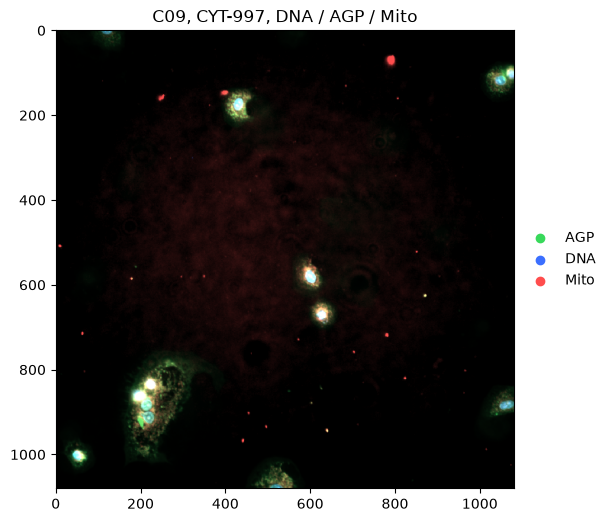

In [13]:
def percentile_norms(
    sdata: sd.SpatialData, element: str, channels: list[str], span: tuple[float, float] = (50.0, 99.9)
) -> list[Normalize]:
    image = get_pyramid_levels(sdata[element], n=0)
    return [Normalize(*np.percentile(image.sel(c=channel).to_numpy(), span)) for channel in channels]


composite = ["DNA", "AGP", "Mito"]
(
    sdatas[plate]
    .pl.render_images(
        f"{plate}_C09_s1_image",
        channel=composite,
        palette=["#3b6fff", "#38d95b", "#ff4d4d"],
        norm=percentile_norms(sdatas[plate], f"{plate}_C09_s1_image", composite),
        channels_as_legend=True,
    )
    .pl.show(coordinate_systems=f"{plate}_C09_s1", figsize=(6, 6), title="C09, CYT-997, DNA / AGP / Mito")
)

## One well

The nine fields of a well drawn in the well coordinate system, which is the transformation doing the work: each image is stored on its own pixel grid and only the translation puts it in place.
The holes are the seven grid positions the microscope did not visit.

Next to it the same well of the other plate, U2OS instead of A549, in its own frame.

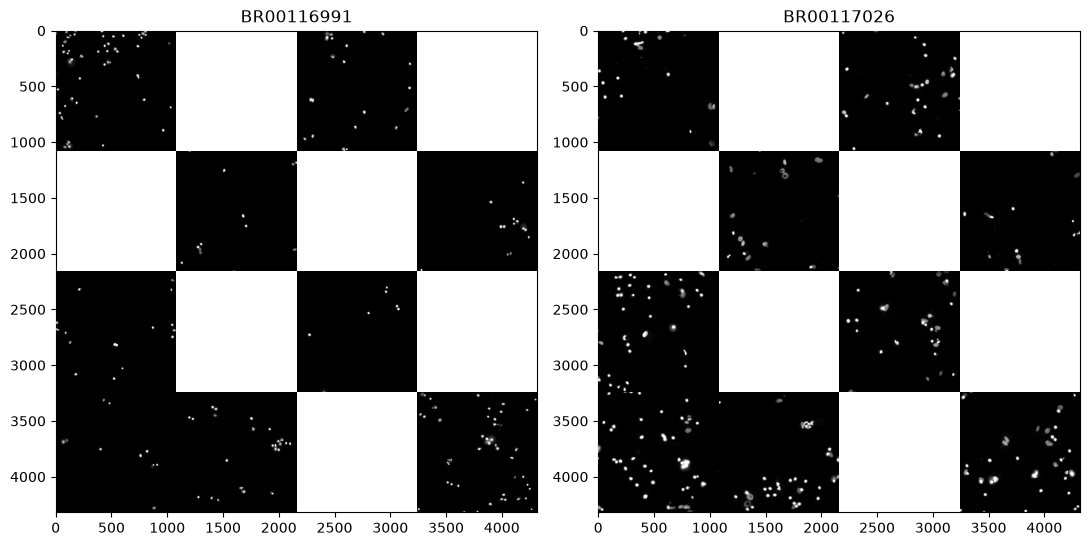

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, plate_name in zip(axes, PLATES, strict=False):
    element = f"{plate_name}_C09_s1_image"
    sdatas[plate_name].pl.render_images(
        channel="DNA", cmap="gray", norm=percentile_norms(sdatas[plate_name], element, ["DNA"])[0], colorbar=False
    ).pl.show(coordinate_systems=f"{plate_name}_C09", ax=ax, title=plate_name)
fig.tight_layout()

## Labels against the image

The cell masks over the DNA channel, coloured by a column of the cell table.
This is the join the label values were built for: `render_labels` looks the object numbers up in `tables["cells"]` through the region column.
`AreaShape_Area` is a raw CellProfiler measurement in pixels, so it doubles as a look at whether the masks landed where the cells are.

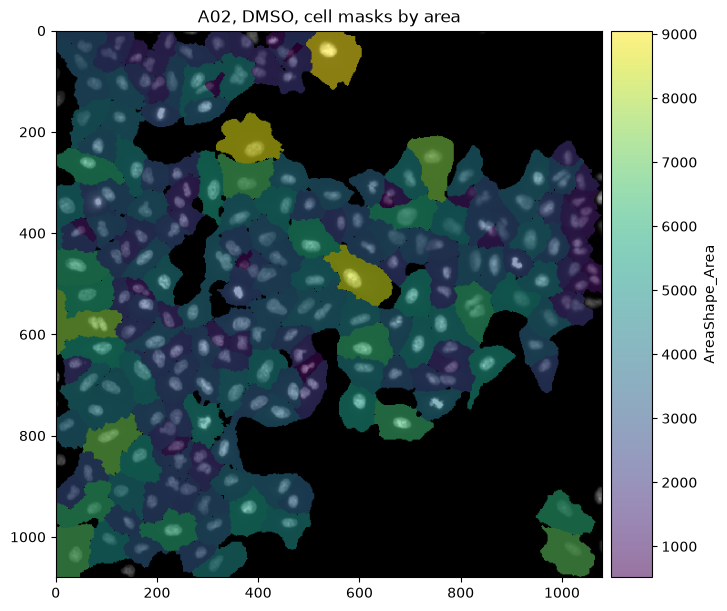

In [15]:
(
    sdatas[plate]
    .pl.render_images(
        f"{plate}_A02_s1_image",
        channel="DNA",
        cmap="gray",
        norm=percentile_norms(sdatas[plate], f"{plate}_A02_s1_image", ["DNA"])[0],
        colorbar=False,
    )
    .pl.render_labels(f"{plate}_A02_s1_cells", color="AreaShape_Area", table_name="cells", fill_alpha=0.55)
    .pl.show(coordinate_systems=f"{plate}_A02_s1", figsize=(6.5, 6), title="A02, DMSO, cell masks by area")
)

## The plate

All 384 wells in the plate coordinate system, coloured from the well-level table.
Only two of these wells have any pixels behind them, but the table is complete, and the plate frame is what makes the control layout visible as a layout.

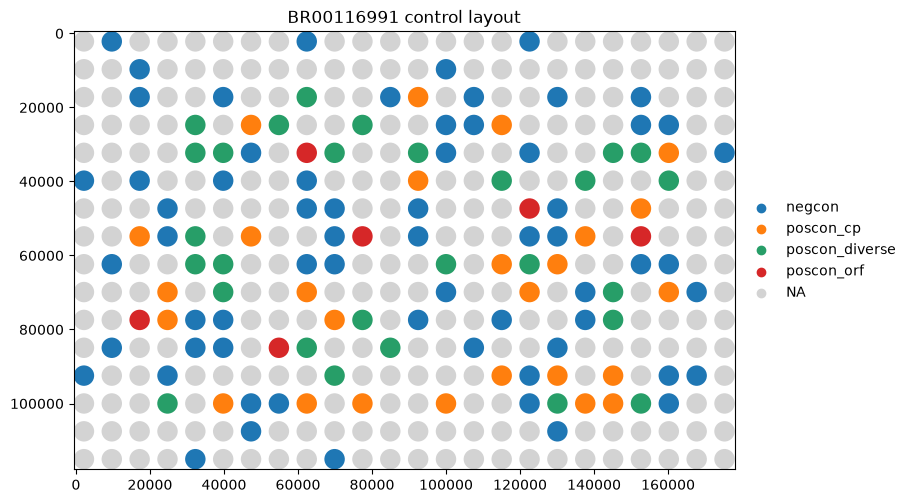

In [16]:
(
    sdatas[plate]
    .pl.render_shapes(f"{plate}_wells", color="control_type", table_name="wells")
    .pl.show(coordinate_systems=plate, figsize=(9, 6), title=f"{plate} control layout")
)

## What is missing

- The stage coordinates are relative to each well, so the plate frame rests on the nominal 4.5 mm pitch of a 384-well plate rather than on anything measured.
  Wells are correct relative to each other only insofar as that pitch is.
- Illumination correction functions ship next to the images, in `images/<batch>/illum/`, and are not applied here; the Images elements hold the raw `Orig` channels, which is not what CellProfiler measured on.
- Only the cell table is per object. Nuclei and cytoplasm have masks but no table; adding them is the same code, and the reason to leave it is memory, roughly 2,000 rows x 1,900 features per plate for two wells and far more for a full plate.
- A wrapper over many plates does not exist yet. `sd.concatenate` handles the merge, but a plate is 700 MB of pixels for two wells, so a full-batch object needs the images kept lazy rather than read up front.